# Black-Scholes Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

In [3]:
def stock_price_monte_carlo(S_0, mu, sigma, N, T, M):
    S = np.zeros((M,N))
    S[:,0] = S_0
    dt = T / N
    for i in range(1, N):
        dS = mu* S[:,i-1] * dt + sigma * S[:,i-1] * np.sqrt(dt) * np.random.standard_normal(M)
        S[:,i] = S[:,i-1] + dS

    return S


In [10]:
S = stock_price_monte_carlo(100, 0.1, 0.1, 252, 1, 50)

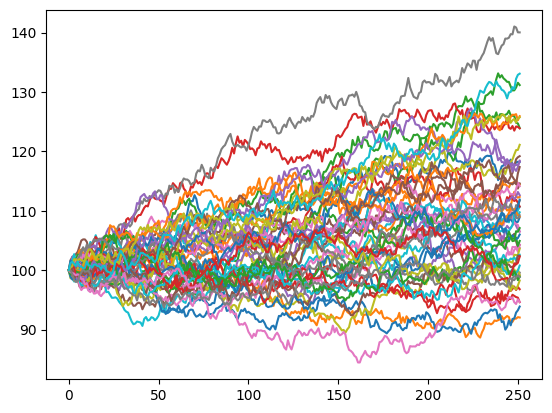

In [12]:
plt.plot(S.T)

In [ ]:
def black_scholes_merton(r, sigma, K, T, S_0, q=None, typ):
    if q is not None:
        S_0 = S_0 * np.exp(-q * T)
    d1 = (np.log(S_0/K) + (r + (sigma**2)/2)*T) / sigma * np.sqrt(T)
    d2 = d1 - sigma * np.sqrt(T)
    if typ == 'call':
        V = S_0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    elif typ == 'put':
        V = K * np.exp(-r*T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1)
    
    return V